# Missing Data Handling — Machine Learning Analysis

## Introduction

Missing values are common in real-world datasets and need to be handled carefully before a machine learning model is trained.

In this activity, missing values are introduced into the Diabetes dataset from Scikit-learn so that different techniques for identifying and handling missing data can be explored. Several imputation strategies are then compared using a Ridge Regression model.

The activity also demonstrates why imputation should be learned from the training data only and how a pipeline can help keep preprocessing and modelling steps organized.

## Objectives

The main objectives of this activity are:

- To identify and inspect missing values in a dataset.
- To create missing values for practice and visualize their pattern.
- To understand the effect of removing incomplete observations.
- To compare different imputation strategies.
- To evaluate imputation approaches using a regression model.
- To understand why imputation parameters should be learned from training data only.
- To use a pipeline to combine imputation, scaling and model training.

## 1. Importing the Required Libraries

The libraries below are used for data manipulation, visualization, missing-value handling, preprocessing, regression modelling and evaluation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## 2. Loading the Dataset

The Diabetes dataset is loaded from Scikit-learn and converted into a pandas DataFrame. This dataset contains numerical features and a continuous target, making it suitable for demonstrating missing-data handling in a regression setting.

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)
df = data.frame.copy()

df.head()



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 2.1 Initial Dataset Inspection

A quick look at the dataset helps confirm the structure of the data before missing values are introduced.

In [3]:
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Observation

The dataset contains numerical predictor variables and a continuous target variable. This makes it appropriate for the regression-based comparison used later in the activity.

## 3. Creating Missing Values for Practice

The original dataset does not contain the missing-value pattern required for this exercise. Therefore, missing values are intentionally introduced into the feature columns.

A fixed random seed is used so that the same missing-value pattern can be reproduced when the notebook is run again.

In [4]:
rng = np.random.default_rng(42)

missing_df = df.copy()

feature_cols = data.feature_names

for col in feature_cols:
    idx = rng.choice(
            missing_df.index,
                    size=int(0.08 * len(missing_df)),
                            replace=False
                                )
    missing_df.loc[idx, col] = np.nan

### 3.1 Checking Missing Values

The number of missing values in each feature is counted to confirm that missing entries have been introduced successfully.

In [5]:
print("Missing values by column:")

missing_counts = (
    missing_df.isna()
        .sum()
            .sort_values(ascending=False)
            )

display(missing_counts)

Missing values by column:


,0
age,35
sex,35
bmi,35
bp,35
s1,35
s2,35
s3,35
s4,35
s5,35
s6,35


### Observation

Missing values are now present across the feature columns, while the target variable remains available for modelling. The missing-value counts provide a quick check of how much information needs to be handled before training the regression model.

## 4. Visualizing the Missing Data Pattern

A heatmap makes it easier to see where missing values occur across the observations and feature columns.

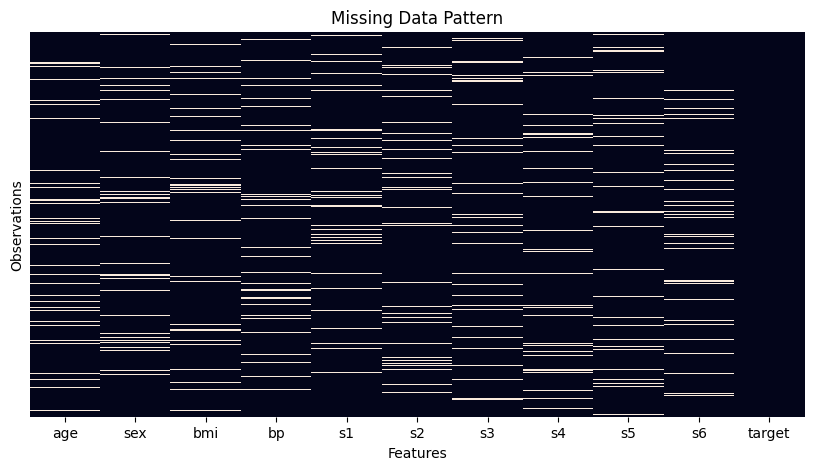

In [6]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    missing_df.isna(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Data Pattern")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.show()

### Observation

The heatmap shows that missing values are distributed across the feature columns rather than being limited to a single variable. This confirms that the dataset contains incomplete observations that need to be handled before model training.

## 5. Complete-Case Deletion

One simple way to handle missing data is to remove every row containing at least one missing value. This is known as complete-case deletion.

Although this approach is straightforward, it can reduce the amount of data available for modelling when missing values occur across many features.

In [7]:
print("Original rows:", len(missing_df))
print(
    "Rows after dropping any missing value:",
        len(missing_df.dropna())
        )

Original rows: 442
Rows after dropping any missing value: 204


### Observation

Removing incomplete rows provides a simple solution, but it may discard a substantial amount of usable information. This is why imputation methods are worth comparing before deciding how missing values should be handled.

## 6. Preparing the Data for Modelling

The features and target are separated before the data is divided into training and testing sets. The target column is kept unchanged because the missing values were introduced only into the feature columns.

In [8]:
X = missing_df.drop(columns="target")
y = missing_df["target"]

### 6.1 Train-Test Split

The dataset is divided into training and testing subsets so that the regression models can be evaluated on data that was not used during training.

An 80:20 split is used for this activity.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (353, 10)
Testing features: (89, 10)
Training target: (353,)
Testing target: (89,)


### Observation

The training and testing sets are kept separate so that the model's performance can be measured on observations that were not used while fitting the model.

## 7. Comparing Missing-Data Imputation Strategies

Instead of removing incomplete rows, missing values can be replaced using different imputation strategies.

The following approaches are compared:

- **Mean:** replaces missing values with the feature mean.
- **Median:** replaces missing values with the feature median.
- **Most Frequent:** uses the most frequently occurring value.
- **Constant:** replaces missing values with a fixed value.
- **KNN:** estimates missing values using information from nearby observations.

Each approach will be combined with standardization and Ridge Regression so that their results can be compared under the same modelling setup.

## 7. Comparing Missing-Data Imputation Strategies

Instead of removing incomplete rows, missing values can be replaced using different imputation strategies.

The following approaches are compared:

- **Mean:** replaces missing values with the feature mean.
- **Median:** replaces missing values with the feature median.
- **Most Frequent:** uses the most frequently occurring value.
- **Constant:** replaces missing values with a fixed value.
- **KNN:** estimates missing values using information from nearby observations.

Each approach will be combined with standardization and Ridge Regression so that their results can be compared under the same modelling setup.

In [10]:
from sklearn.impute import SimpleImputer, KNNImputer

strategies = {
    "Mean": SimpleImputer(strategy="mean"),
        "Median": SimpleImputer(strategy="median"),
            "Most Frequent": SimpleImputer(strategy="most_frequent"),
                "Constant": SimpleImputer(strategy="constant", fill_value=0),
                    "KNN": KNNImputer(n_neighbors=5)
                    }

### 7.2 Building the Comparison Pipelines

A pipeline is created for each strategy. The pipeline first handles the missing values, then standardizes the features, and finally fits a Ridge Regression model.

Using the same sequence for every strategy makes the comparison more consistent.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

rows = []

for name, imputer in strategies.items():
    pipe = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    rows.append({
        "Strategy": name,
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

results = pd.DataFrame(rows)

display(results)

,Strategy,RMSE,R2
0,Mean,57.828508,0.368811
1,Median,57.972657,0.365660
2,Most Frequent,59.326259,0.335692
3,Constant,57.868567,0.367936
4,KNN,56.398278,0.399646


### 7.3 Model Comparison

The results table compares the imputation strategies using two regression metrics:

- **RMSE:** measures the typical size of prediction errors, with lower values indicating better performance.
- **R²:** indicates how much of the variation in the target is explained by the model, with higher values generally indicating better performance.

Both metrics are considered when comparing the strategies.

### Observation

The results show that the choice of imputation method can affect the final regression performance. The strategy with the lowest RMSE and the strategy with the highest R² provide useful indications of which approach performs better on this test set.

## 8. Preventing Data Leakage

Imputation should be learned from the training data rather than from the complete dataset. Otherwise, information from the test set could influence the preprocessing step before the model is evaluated.

The following example demonstrates that the imputer is fitted on the training data and then applied to the testing data.

### 8.1 Fitting the Imputer on Training Data Only

In [13]:
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

print(
    "Training missing values after imputation:",
        np.isnan(X_train_imp).sum()
        )

print(
    "Testing missing values after imputation:",
        np.isnan(X_test_imp).sum()
        )

Training missing values after imputation: 0
Testing missing values after imputation: 0


### Observation

The imputer learns its replacement values from the training set and then applies those values to the test set. After imputation, the remaining missing-value count should be zero for both sets.

## 9. Overall Interpretation

This activity shows that missing values can be handled in several ways, and the choice of method can influence the performance of a machine learning model.

Simple deletion is easy to apply but can reduce the amount of available data. Imputation retains those observations, while different imputation strategies may produce different modelling results.

The comparison also demonstrates the importance of fitting preprocessing steps only on training data to avoid information from the test set influencing the evaluation.

## 10. Conclusion

This activity demonstrated several approaches for identifying and handling missing data.

Artificial missing values were introduced into the feature columns and their distribution was examined using counts and a heatmap. Complete-case deletion was then considered before comparing mean, median, most-frequent, constant and KNN imputation with a Ridge Regression model.

The model comparison shows why the imputation method should be evaluated rather than selected automatically. The activity also demonstrated that preprocessing parameters should be learned from the training data only, which helps maintain a fair evaluation of the model.

## 11. Practice Questions

The following questions reinforce the main concepts covered in this activity.

1. Why should imputation parameters be learned from training data only?

2. When is median imputation preferable to mean imputation?

3. What are the risks of deleting every row containing a missing value?

4. Why is a pipeline useful when handling missing data?